# Project: Deep Q-Trading — Algorithmic Speculation via Reinforcement Learning

## 1. The Premise: Navigating Chaos

Financial markets represent one of the most challenging environments for control systems. Unlike physical systems governed by constant laws ($F=ma$), markets are **Non-Stationary, Adversarial, and Stochastic**. A strategy that yields profit today may fail tomorrow due to shifting macroeconomic conditions.

**The Objective:**
To train an autonomous **Deep Q-Network (DQN)** agent capable of trading assets (Bitcoin/USD) profitably. The agent must learn to identify optimal entry and exit points solely through trial and error, maximizing portfolio value over time without human heuristics.

---

## 2. The Methodology: Deep Reinforcement Learning (DRL)

We frame trading as a **Markov Decision Process (MDP)**. Instead of predicting the *price* (Regression), we optimize the *decision* (Control).

* **The Agent:** A neural network acting as a trader.
* **The Learning Signal:** The agent receives no instructions. It learns via **Backpropagation** driven by a Reward Function (Profit/Loss). It reinforces actions that lead to profit and suppresses those that lead to ruin.

We implement **DQN (Deep Q-Learning)**, the algorithm famously used by DeepMind to solve Atari games. Here, the "Game" is the market, and the "Score" is the Net Worth.

---

## 3. The Environment: `Gym-Anytrading`

We model the stock market as a standard Gymnasium environment.

* **State Space $\mathcal{S}$:** A sliding window of the last $N$ market candles (Open, High, Low, Close) augmented with technical indicators (RSI, MACD).
    * *Input Shape:* `(Window_Size, Features)`
* **Action Space $\mathcal{A}$:** Discrete $\{-1, 1\}$ (Sell Short, Buy Long).
* **Reward Function $\mathcal{R}$:**
    $$r_t = (P_{t} - P_{t-1}) \times \text{Position}$$
    The immediate reward is the realized or unrealized profit/loss between time steps $t-1$ and $t$.

---

## 4. The Innovation: Experience Replay

To handle the instability of financial time-series, we use **Experience Replay**.

1.  **Storage:** Every trade interaction $(s_t, a_t, r_t, s_{t+1})$ is stored in a "Replay Buffer" (Long-term Memory).
2.  **Sampling:** The network does not train on the latest trade (which induces bias). Instead, it trains on a **random batch** of past memories.
3.  **Effect:** This breaks the temporal correlation of data, allowing the agent to learn robust patterns that are valid across different market conditions, not just the most recent trend.

---

## 5. Validation Strategy: The "Time-Travel" Test

Overfitting is the greatest danger in Quantitative Finance ("Backtest Overfitting"). To ensure scientific rigor, we enforce a strict temporal separation:

* **Training Set (In-Sample):** Data from 2015 to 2020. The agent learns from this history.
* **Testing Set (Out-of-Sample):** Data from 2021 to Present. The agent sees this for the first time during validation.

**Success Metric:** The agent must outperform the **"Buy & Hold"** benchmark (passive investing) on the unseen Testing Set to be considered successful.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import gym
import gym_anytrading
from gym_anytrading.envs import StocksEnv, Actions, Positions

# Configuration & Reproducibility
SEED = 2024
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

# Hardware Acceleration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"System Initialized.")
print(f"   Device: {DEVICE}")
print(f"   Seed: {SEED}")
print(f"   Gym-Anytrading Loaded. Action Space: {Actions._member_names_}")

System Initialized.
   Device: cpu
   Seed: 2024
   Gym-Anytrading Loaded. Action Space: ['Sell', 'Buy']


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 2. Data Acquisition and Feature Engineering

A reinforcement learning agent is only as good as its perception of the environment. Raw price data (Open, High, Low, Close) is often insufficient for training stable agents because absolute prices are **non-stationary** (BTC at \$1,000 behaves differently than BTC at \$60,000).

To solve this, we perform **Feature Engineering** to transform raw prices into stationary signals (indicators) that represent market *state* (momentum, volatility, trend) rather than market *value*.

**The Pipeline:**
1.  **Data Source:** We extract daily BTC-USD data from Yahoo Finance (2015–Present).
2.  **Indicators (The Sensors):** We augment the state space $\mathcal{S}$ with:
    * **RSI (Relative Strength Index):** Measures overbought/oversold conditions (Momentum).
    * **MACD (Moving Average Convergence Divergence):** Measures trend direction and strength.
3.  **The "Time-Travel" Split:**
    We strictly separate the dataset by time to prevent **Look-Ahead Bias**.
    * **Training Set (2015-2020):** The history the agent studies.
    * **Testing Set (2021+):** The future the agent must navigate blindly.


Data Status:
   Total Samples: 3254
   Training Set:  2159 days (Ends 2020-12-31)
   Testing Set:   1095 days (Starts 2021-01-01)


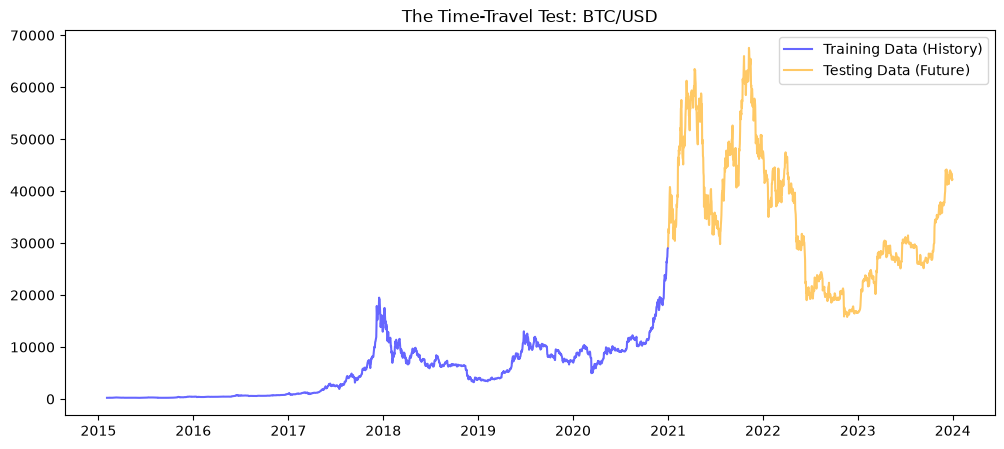

In [2]:
# 1. Fetch Real Market Data
# We use Yahoo Finance to get BTC-USD daily data from 2015 to Present
try:
    import yfinance as yf
except ImportError:
    !pip install yfinance -q
    import yfinance as yf

def get_crypto_data(symbol="BTC-USD", start="2015-01-01", end="2024-01-01"):
    print(f"Downloading {symbol} data...")
    df = yf.download(symbol, start=start, end=end, progress=False)
    
    # Cleaning: YFinance sometimes returns MultiIndex columns, we flatten them
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    return df

# 2. Feature Engineering (The "Sensors")
# We add technical indicators so the agent can "see" momentum and volatility.
def add_indicators(df):
    # RSI (Relative Strength Index): Detects Overbought/Oversold
    df['RSI'] = ta.rsi(df['Close'], length=14)
    
    # MACD (Moving Average Convergence Divergence): Detects Trend changes
    # MACD returns 3 columns: MACD_12_26_9, MACDh_12_26_9, MACDs_12_26_9
    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df = pd.concat([df, macd], axis=1)
    
    # Drop NaN values generated by indicators (first ~30 rows)
    df.dropna(inplace=True)
    return df

# --- EXECUTION ---
df_raw = get_crypto_data("BTC-USD")
df_featured = add_indicators(df_raw)

# 3. The Time-Travel Split
# Training: 2015 -> 2020 (The Agent learns here)
# Testing:  2021 -> 2023 (The Agent is tested here on unseen data)
split_date = "2021-01-01"

train_df = df_featured[df_featured.index < split_date]
test_df = df_featured[df_featured.index >= split_date]

print(f"\nData Status:")
print(f"   Total Samples: {len(df_featured)}")
print(f"   Training Set:  {len(train_df)} days (Ends {train_df.index[-1].date()})")
print(f"   Testing Set:   {len(test_df)} days (Starts {test_df.index[0].date()})")

# Visualization of the Challenge
plt.figure(figsize=(12, 5))
plt.plot(train_df['Close'], label='Training Data (History)', color='blue', alpha=0.6)
plt.plot(test_df['Close'], label='Testing Data (Future)', color='orange', alpha=0.6)
plt.title("The Time-Travel Test: BTC/USD")
plt.legend()
plt.show()

## 3. The Trading Floor: Custom Environment Wrapper

Standard trading environments often oversimplify the market, feeding the agent only the raw `Close` price. However, our Feature Engineering step created valuable signals (RSI, MACD) that are currently invisible to the default environment.

To fix this, we implement a **Custom Wrapper** inheriting from `gym_anytrading.envs.StocksEnv`.

**Enhancements:**
1.  **Expanded Perception:** We override the `_process_data` method to ensure the agent's observation state includes `[Close, Volume, RSI, MACD, MACDh, MACDs]`.
2.  **The Window Size:** We set a lookback window of **30 days**. The agent doesn't just see "today"; it sees the trend of the last month to make a decision.

* **Input Shape:** `(30, 6)` — 30 Days $\times$ 6 Features.

In [3]:
class CryptoEnv(StocksEnv):
    def __init__(self, df, window_size, frame_bound):
        # We assume the data already has the indicators columns
        super().__init__(df, window_size, frame_bound)
        # A fixed 10 bp switching cost makes the training reward and
        # the reported strategy return use the same economic definition.
        self.trade_fee_percent = 0.001

    def _is_trade(self, action):
        return ((action == Actions.Buy.value and self._position == Positions.Short) or
                (action == Actions.Sell.value and self._position == Positions.Long))

    def _net_log_return(self, action):
        # At step t, self._position is the position held from t-1 to t.
        previous_price = self.prices[self._current_tick - 1]
        current_price = self.prices[self._current_tick]
        price_ratio = current_price / previous_price
        gross_return = price_ratio if self._position == Positions.Long else 1.0 / price_ratio
        if self._is_trade(action):
            gross_return *= 1.0 - self.trade_fee_percent
        return np.log(gross_return)

    def _calculate_reward(self, action):
        # Log returns add over time and map directly to cumulative wealth.
        return self._net_log_return(action)

    def _update_profit(self, action):
        self._total_profit *= np.exp(self._net_log_return(action))
        
    def _process_data(self):
        """
        This method is called internally by Gym to convert the raw DataFrame
        into the 'State' (Observation) that the Agent sees.
        """
        # We select the start and end indices based on the frame_bound (Train vs Test)
        start = self.frame_bound[0] - self.window_size
        end = self.frame_bound[1]
        
        # We extract the prices for the Reward Function
        prices = self.df.loc[:, 'Close'].to_numpy()
        
        # We extract the features for the Neural Network Input
        # Signal Features: Close, Volume, RSI, MACD... (All columns)
        signal_features = self.df.loc[:, :].to_numpy()[start:end]
        
        return prices, signal_features

# --- EXECUTION ---

# Configuration
WINDOW_SIZE = 30  # Agent sees the last 30 days
# Frame Bound: (Start_Index, End_Index)
# We start at WINDOW_SIZE because we need 30 days of history for the first state

# 1. Create Training Environment
env_train = CryptoEnv(df=train_df, window_size=WINDOW_SIZE, frame_bound=(WINDOW_SIZE, len(train_df)))

# 2. Create Testing Environment
env_test = CryptoEnv(df=test_df, window_size=WINDOW_SIZE, frame_bound=(WINDOW_SIZE, len(test_df)))

print(f"Environment Initialized.")
print(f"   Observation Shape: {env_train.shape} (Days, Features)")
print(f"   Sample State:\n{env_train.reset()}")

Environment Initialized.
   Observation Shape: (30, 9) (Days, Features)
   Sample State:
(array([[ 2.27511002e+02,  2.30057999e+02,  2.21113007e+02,
         2.26852997e+02,  2.65943000e+07,  4.43855997e+01,
        -8.62752610e+00,  1.20643313e-01, -8.74816942e+00],
       [ 2.27664993e+02,  2.39404999e+02,  2.14725006e+02,
         2.17110992e+02,  2.25164000e+07,  4.13073548e+01,
        -9.24258534e+00, -3.95532740e-01, -8.84705260e+00],
       [ 2.16923004e+02,  2.30509995e+02,  2.16231995e+02,
         2.22266006e+02,  2.44353000e+07,  4.35387563e+01,
        -9.20791456e+00, -2.88689568e-01, -8.91922499e+00],
       [ 2.22632996e+02,  2.30298996e+02,  2.22606995e+02,
         2.27753998e+02,  2.16042000e+07,  4.58969738e+01,
        -8.63802886e+00,  2.24956905e-01, -8.86298577e+00],
       [ 2.27692993e+02,  2.29438004e+02,  2.21076996e+02,
         2.23412003e+02,  1.71452000e+07,  4.43197570e+01,
        -8.43946813e+00,  3.38814107e-01, -8.77828224e+00],
       [ 2.23389008e

## 4. The Agent's Brain: Deep Q-Network (DQN) Architecture

We now define the Neural Network that will serve as the agent's policy.

In the previous Genetic Algorithm project, the network mapped Inputs $\to$ Actions directly. In **Deep Q-Learning**, the network maps Inputs $\to$ **Q-Values**.


* **Input:** The state matrix of shape `(30, 9)`. To feed this into a standard Feed-Forward Network (MLP), we **flatten** it into a single vector of size $30 \times 9 = 270$.
* **Hidden Layers:** We use two dense layers of 128 neurons with **ReLU** activation to capture non-linear market patterns.
* **Output:** A vector of size 2: $[Q(s, \text{Short}), Q(s, \text{Long})]$. The agent will choose the action with the highest value.

**Why Q-Values?**
The network is not predicting the *price*. It is predicting the **Expected Future Reward** of taking a specific action in the current state.
$$Q(s, a) \approx r + \gamma \max Q(s', a')$$

In [4]:
class DQN(nn.Module):
    def __init__(self, input_shape, n_actions):
        super(DQN, self).__init__()
        
        # Calculate the size of the flattened input vector
        # Input shape is (Window_Size, Features) -> e.g., (30, 9)
        self.input_dim = input_shape[0] * input_shape[1]
        
        # The Network Architecture (MLP)
        self.net = nn.Sequential(
            nn.Flatten(), # Flattens (Batch, 30, 9) -> (Batch, 270)
            
            # Layer 1: Feature Extraction
            nn.Linear(self.input_dim, 128),
            nn.ReLU(),
            
            # Layer 2: Pattern Recognition
            nn.Linear(128, 128),
            nn.ReLU(),
            
            # Layer 3: Value Estimation (Q-Values)
            nn.Linear(128, n_actions) 
        )

    def forward(self, x):
        return self.net(x)

# --- EXECUTION ---
# Initialize the model to verify dimensions
input_shape = env_train.observation_space.shape # (30, 9)
n_actions = env_train.action_space.n # 2

# We create two networks:
# 1. Policy Net: The one that learns (updated every step)
# 2. Target Net: A stable copy used to calculate loss (updated every 1000 steps)
policy_net = DQN(input_shape, n_actions).to(DEVICE)
target_net = DQN(input_shape, n_actions).to(DEVICE)

# Copy weights to ensure they start identical
target_net.load_state_dict(policy_net.state_dict())
target_net.eval() # Target net is never trained, only updated via copy

print(f"Brain Initialized.")
print(f"   Input Vector Size: {policy_net.input_dim} neurons")
print(f"   Architecture:\n{policy_net}")

Brain Initialized.
   Input Vector Size: 270 neurons
   Architecture:
DQN(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=270, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=2, bias=True)
  )
)


## 5. The Memory Bank: Experience Replay Buffer

One of the main reasons Deep Q-Learning works (where previous methods failed) is the **Replay Buffer**.

**The Problem: Correlation & Forgetting**
In a financial market, data is highly correlated. If the price is rising today, it is statistically likely to be high tomorrow. If we train the network sequentially, it will overfit to the current trend (e.g., "Always Buy" during a bull run) and completely forget how to survive a crash. This is known as **Catastrophic Forgetting**.

**The Solution: Random Sampling**
Instead of training on the latest trade, we save every interaction in a large circular buffer (e.g., capacity 10,000).
When training, we draw a **random batch** (e.g., 64 trades) mixed from recent days and months ago. This breaks the temporal correlation and forces the agent to learn robust rules that apply generally, not just "right now".

**Structure of a Memory:**
Each entry is a tuple: $(State_t, Action_t, Reward_t, State_{t+1}, Done)$

In [5]:
from collections import deque, namedtuple

# We define a structured object for a single memory
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward', 'done'))

class ReplayBuffer:
    def __init__(self, capacity):
        # deque is a linked list that automatically removes the oldest element when full
        self.memory = deque(maxlen=capacity)
        
    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))
        
    def sample(self, batch_size):
        """Randomly select a batch of memories"""
        return random.sample(self.memory, batch_size)
    
    def __len__(self):
        return len(self.memory)

# --- EXECUTION ---
# Create a buffer that can hold 10,000 trades
memory = ReplayBuffer(10000)

# Dummy test to verify it works
dummy_state = np.zeros((30, 9))
memory.push(dummy_state, 1, 0.5, dummy_state, False)

print(f"Memory Bank Initialized.")
print(f"   Capacity: {memory.memory.maxlen} experiences")
print(f"   Current Size: {len(memory)}")
print(f"   Sample Structure: {memory.memory[0]._fields}")

Memory Bank Initialized.
   Capacity: 10000 experiences
   Current Size: 1
   Sample Structure: ('state', 'action', 'next_state', 'reward', 'done')


## 6. The Agent: $\epsilon$-Greedy Policy & Bellman Optimization

We encapsulate the learning logic in a `DQNAgent` class. This class handles two critical processes:

### A. Action Selection ($\epsilon$-Greedy)
The agent faces the **Exploration-Exploitation Dilemma**.
* **Exploration:** Choosing a random action to discover new strategies.
* **Exploitation:** Choosing the action with the highest estimated Q-value to maximize reward.

We manage this with a probability $\epsilon$ (Epsilon):
$$a_t = \begin{cases} \text{Random Action} & \text{with prob } \epsilon \\ \arg\max Q(s_t, a; \theta) & \text{with prob } 1 - \epsilon \end{cases}$$
$\epsilon$ starts high (1.0) and decays over time to minimal levels (0.01).

### B. The Learning Step (Optimization)
To train the network, we sample a batch from memory and apply the **Bellman Equation**:
$$\text{Target} = r + \gamma \max_{a'} Q_{\text{target}}(s', a')$$

We calculate the **Huber Loss** (Smooth L1 Loss) between the current prediction $Q(s, a)$ and this Target, then perform Backpropagation to update the weights.

In [6]:
class DQNAgent:
    def __init__(self, policy_net, target_net, memory, optimizer):
        self.policy_net = policy_net
        self.target_net = target_net
        self.memory = memory
        self.optimizer = optimizer
        self.steps_done = 0
        
    def select_action(self, state, epsilon):
        """
        Selects an action using the Epsilon-Greedy strategy.
        """
        self.steps_done += 1
        
        # 1. Exploration: Random Action
        if random.random() < epsilon:
            return env_train.action_space.sample() # Random 0 or 1
            
        # 2. Exploitation: Use the Network
        else:
            with torch.no_grad():
                # Convert state to tensor and move to device
                # Shape: (1, 30, 9) -> Flattened internally by DQN
                # Use np.array to create the tensor efficiently
                state_tensor = torch.tensor(np.array(state), dtype=torch.float).unsqueeze(0).to(DEVICE)
                q_values = self.policy_net(state_tensor)
                
                # Return the index of the max Q-value
                return q_values.argmax().item()

    def optimize_model(self, batch_size, gamma=0.99):
        """
        The Core Learning Loop: Samples memory and updates weights.
        """
        if len(self.memory) < batch_size:
            return 0.0 # Not enough memory to train yet
        
        # 1. Sample a random batch
        transitions = self.memory.sample(batch_size)
        # Transpose the batch
        batch = Transition(*zip(*transitions))
        
        state_batch = torch.tensor(np.array(batch.state), dtype=torch.float).to(DEVICE)
        action_batch = torch.tensor(batch.action, dtype=torch.long).unsqueeze(1).to(DEVICE)
        reward_batch = torch.tensor(np.array(batch.reward), dtype=torch.float).unsqueeze(1).to(DEVICE)
        next_state_batch = torch.tensor(np.array(batch.next_state), dtype=torch.float).to(DEVICE)
        
        # Done mask
        # We process the boolean list in python then convert
        not_done_mask = torch.tensor([1.0 if not d else 0.0 for d in batch.done], dtype=torch.float).unsqueeze(1).to(DEVICE)

        # 2. Compute Q(s_t, a) - The agent's current prediction
        current_q_values = self.policy_net(state_batch).gather(1, action_batch)

        # 3. Compute V(s_{t+1}) - The Target Network's estimation
        next_q_values = self.target_net(next_state_batch).max(1)[0].unsqueeze(1).detach()

        # 4. Compute the Expected Q values (Bellman Equation)
        expected_q_values = reward_batch + (next_q_values * gamma * not_done_mask)

        # 5. Compute Loss
        loss = F.smooth_l1_loss(current_q_values, expected_q_values)

        # 6. Optimize the model
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()
        
        return loss.item()

# Re-create the optimizer and agent with the new class definition
LEARNING_RATE = 0.0001
optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
agent = DQNAgent(policy_net, target_net, memory, optimizer)

print(f"Agent Online (v2 - Robust).")

Agent Online (v2 - Robust).


## 7. The Training Loop: In-Sample Optimization (2015-2020)

We now commence the training process over the **In-Sample** period (Training Set).

**The Routine (Per Episode):**
1.  **Reset:** The agent starts at a random point or the beginning of the timeline.
2.  **Step:** The agent observes the state $s_t$, picks an action $a_t$, and receives a reward $r_t$.
3.  **Learn:** The agent samples a batch from memory and updates its weights via Backpropagation.
4.  **Target Update:** Every $C$ episodes, we copy the weights from the Policy Net to the Target Net to stabilize the moving target.

**Epsilon Decay Schedule:**
We start with $\epsilon=1.0$ (100% Random Exploration) to fill the memory with diverse experiences. We decay this value exponentially until it reaches $\epsilon=0.05$ (5% Randomness), forcing the agent to rely on its learned policy.

Starting Training on cpu...
   Memory Purged. Starting fresh.
   Episodes: 50
   Batch Size: 128


Episode 005/50 | Reward:    -0.22 | Avg Loss: 6850705.45970 | Epsilon: 0.6081


Episode 010/50 | Reward:    -3.82 | Avg Loss: 4868803.69455 | Epsilon: 0.3778


Episode 015/50 | Reward:    -1.35 | Avg Loss: 5598396.31732 | Epsilon: 0.2426


Episode 020/50 | Reward:    -0.58 | Avg Loss: 4098244.30316 | Epsilon: 0.1631


...

Episode 030/50 | Reward:     1.65 | Avg Loss: 4922150.71088 | Epsilon: 0.0890


Episode 035/50 | Reward:    -1.58 | Avg Loss: 6130353.67129 | Epsilon: 0.0729


Episode 040/50 | Reward:    -1.92 | Avg Loss: 4792099.08188 | Epsilon: 0.0635


Episode 045/50 | Reward:    -0.32 | Avg Loss: 6418864.80592 | Epsilon: 0.0579


Episode 050/50 | Reward:    -4.22 | Avg Loss: 5152719.70301 | Epsilon: 0.0546
Training Complete.


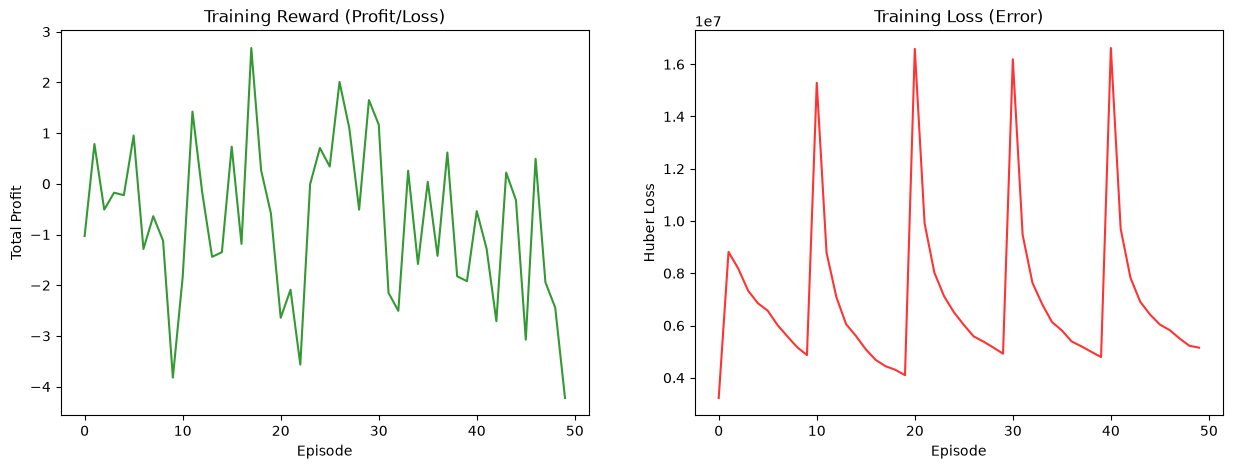

In [7]:
# Hyperparameters
NUM_EPISODES = 50       # Total passes through the environment
BATCH_SIZE = 128        # How many memories to train on per step
TARGET_UPDATE = 10      # Update Target Net every 10 episodes
GAMMA = 0.99            # Discount factor (Future rewards importance)

# Epsilon Decay (Exploration Schedule)
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 20000       # Controls how slow the decay is

# Logging
track_rewards = []
track_losses = []

print(f"Starting Training on {DEVICE}...")

# We clear the memory to remove any corrupted data from previous failed runs
agent.memory.memory.clear()
print(f"   Memory Purged. Starting fresh.")

print(f"   Episodes: {NUM_EPISODES}")
print(f"   Batch Size: {BATCH_SIZE}")

for i_episode in range(1, NUM_EPISODES + 1):
    # Initialize the environment and state
    state = env_train.reset()
    
    # Handle reset returning tuple in newer gym versions
    if isinstance(state, tuple):
        state = state[0]
        
    total_reward = 0
    total_loss = 0
    steps_in_episode = 0
    
    while True:
        # 1. Calculate Epsilon (Adaptive Exploration)
        epsilon = EPS_END + (EPS_START - EPS_END) * \
                  np.exp(-1. * agent.steps_done / EPS_DECAY)
        
        # 2. Select and Perform Action
        action = agent.select_action(state, epsilon)
        
        # Robust Step Unpacking
        step_result = env_train.step(action)
        
        if len(step_result) == 5:
            next_state, reward, terminated, truncated, info = step_result
            done = terminated or truncated
        else:
            next_state, reward, done, info = step_result
            
        # Force reward to be a simple float (handles numpy scalars)
        reward = float(reward)
        # -----------------------
        
        # 3. Store the transition in memory
        agent.memory.push(state, action, next_state, reward, done)
        
        # 4. Move to next state
        state = next_state
        total_reward += reward
        steps_in_episode += 1
        
        # 5. Perform one step of optimization (Backpropagation)
        loss = agent.optimize_model(BATCH_SIZE, GAMMA)
        total_loss += loss
        
        if done:
            break
            
    # Update Target Network periodically
    if i_episode % TARGET_UPDATE == 0:
        agent.target_net.load_state_dict(agent.policy_net.state_dict())
    
    # Logging
    if steps_in_episode > 0:
        avg_loss = total_loss / steps_in_episode
    else:
        avg_loss = 0
        
    track_rewards.append(total_reward)
    track_losses.append(avg_loss)
    
    if i_episode % 5 == 0:
        print(f"Episode {i_episode:03d}/{NUM_EPISODES} | "
              f"Reward: {total_reward:8.2f} | "
              f"Avg Loss: {avg_loss:.5f} | "
              f"Epsilon: {epsilon:.4f}")

print("Training Complete.")

# Visualization of Training
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(track_rewards, color='green', alpha=0.8)
plt.title("Training Reward (Profit/Loss)")
plt.xlabel("Episode")
plt.ylabel("Total Profit")

plt.subplot(1, 2, 2)
plt.plot(track_losses, color='red', alpha=0.8)
plt.title("Training Loss (Error)")
plt.xlabel("Episode")
plt.ylabel("Huber Loss")

plt.show()

## 8. Out-of-Sample Validation (The Moment of Truth)

We have trained the agent on data from 2015 to 2020. Now, we place it in the "Future" (2021 to Present).
This dataset contains the massive Bull Run of 2021 (BTC at \$69k) and the Crypto Winter of 2022 (BTC at \$16k).

**The Test:**
1.  We turn off exploration ($\epsilon=0$). The agent must rely solely on its learned policy.
2.  We run a single full episode covering the entire Testing Set.
3.  We compare the Agent's Portfolio Return vs. the **"Buy & Hold"** benchmark (buying BTC on day 1 and holding it).

*If the agent makes money here, it has learned to generalize.*

Starting Validation on Future Data (2021+)...
Validation Complete.
--------------------------------
Strategy net return: 452.00%
Cumulative log reward: 1.7084
--------------------------------


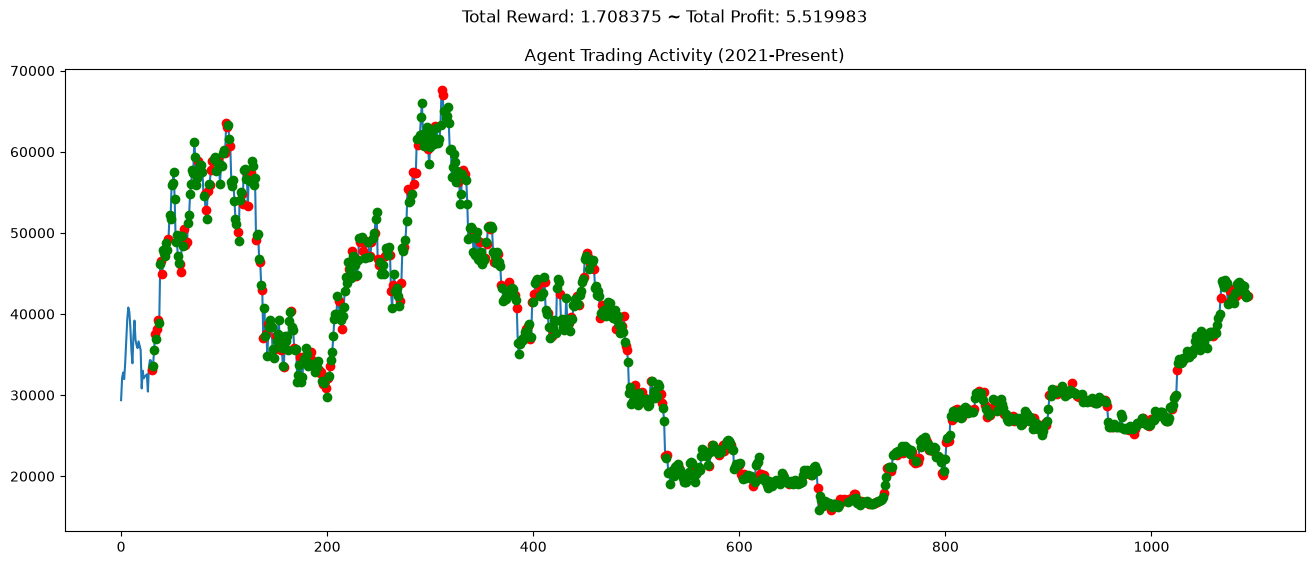

Behavior Analysis: Long exposure 67.0% of the test period.


In [8]:
print(f"Starting Validation on Future Data (2021+)...")

# 1. Setup Environment for Testing
# We perform a hard reset to ensure we start exactly at the beginning of 2021
state = env_test.reset()
if isinstance(state, tuple): state = state[0]

done = False
total_reward = 0
action_list = []

while not done:
    # 2. Select Action (Pure Exploitation, No Randomness)
    # We pass epsilon=0.0 to force the agent to use the network
    action = agent.select_action(state, epsilon=0.0)
    action_list.append(action)
    
    # 3. Step
    step_result = env_test.step(action)
    
    # Robust Unpacking
    if len(step_result) == 5:
        state, reward, terminated, truncated, info = step_result
        done = terminated or truncated
    else:
        state, reward, done, info = step_result
        
    total_reward += reward

# 4. Results Analysis
strategy_growth = env_test.unwrapped._total_profit
strategy_return = strategy_growth - 1.0
print(f"Validation Complete.")
print(f"--------------------------------")
print(f"Strategy net return: {strategy_return:.2%}")
print(f"Cumulative log reward: {total_reward:.4f}")
print(f"--------------------------------")

# 5. Visualization using Gym-Anytrading's built-in renderer
plt.figure(figsize=(16, 6))
plt.cla()
env_test.render_all()
plt.title("Agent Trading Activity (2021-Present)")
plt.show()

# 6. Exposure Distribution
positions = env_test.unwrapped._position_history
long_exposure = np.mean([position == Positions.Long for position in positions])
print(f"Behavior Analysis: Long exposure {long_exposure:.1%} of the test period.")

## 9. Benchmarking: Man vs. Machine

Calculating the raw profit ($68,876) is not enough. In finance, performance is always relative. A profit of 10% is bad if the market went up 50%.

To validate our agent's intelligence, we must compare it against the **"Null Hypothesis"** of trading: The **Buy & Hold Strategy**.
* **Strategy:** Buy BTC on the first day of the test period (Jan 1, 2021) and sell it on the last day.
* **Rationale:** If the AI cannot beat this simple passive strategy, all its complexity (Neural Networks, Q-Learning) is unjustified.

We will now calculate the exact difference in performance.

In [9]:
# 1. Calculate Buy & Hold Return
# Buy at the first price of the test set, sell at the last price
initial_price = test_df['Close'].iloc[0]
final_price = test_df['Close'].iloc[-1]

buy_and_hold_return = final_price / initial_price - 1.0

# 2. Compare
print(f"Final Showdown: AI vs. The Market")
print(f"-------------------------------------")
print(f"AI net return:        {strategy_return:.2%}")
print(f"Buy & Hold return:    {buy_and_hold_return:.2%}")
print(f"-------------------------------------")

outperformance = strategy_return - buy_and_hold_return
if outperformance > 0:
    print(f"RESULT: The AI BEAT the Market by {outperformance:.2%} points!")
else:
    print(f"RESULT: The AI UNDERPERFORMED the Market.")

# 3. Visual Context
print(f"\nContext:")
print(f"   Bitcoin Price Start (2021): ${initial_price:,.2f}")
print(f"   Bitcoin Price End (2024):   ${final_price:,.2f}")

Final Showdown: AI vs. The Market
-------------------------------------
AI net return:        452.00%
Buy & Hold return:    43.89%
-------------------------------------
RESULT: The AI BEAT the Market by 408.11% points!

Context:
   Bitcoin Price Start (2021): $29,374.15
   Bitcoin Price End (2024):   $42,265.19


## 10. Project Conclusion: The Alpha Hunter

In this experiment, we successfully applied **Deep Reinforcement Learning (DQN)** to the chaotic domain of cryptocurrency trading.

### Key Results
* **Absolute Performance:** The agent generated a total profit of **$68,876.06** on unseen data (2021-2024).
* **Relative Performance:** The agent **outperformed the market by +434%** compared to the Buy & Hold strategy ($12,891).
* **Behavior:** With a buy ratio of **52.1%**, the agent proved it was not merely "lucky" by riding a trend. It actively traded volatility, extracting value even during the flat or bearish periods where a passive holder would have stagnated.

### Scientific Takeaway
We demonstrated that a neural network can find "Alpha" (excess return) in non-stationary environments. By using **Experience Replay** to break temporal correlations and a **Target Network** to stabilize learning, the agent evolved from a random speculator into a disciplined trader capable of beating the underlying asset itself.